# Notebook 11 — Değerlendirme (Tam)

v1 modeli (advanced_v1), test seti. Yeniden eğitim YOK.

**A) Patch-level metrikler:** AUC + bootstrap %95 CI (det & mal), malignancy confusion matrix (sens/spec/F1), Dice dağılımı, kalibrasyon (Brier).

**B) Gerçek scan-level FROC:** ham CT (NPZ) + candidates.csv + split_meta.json ile LUNA16 resmi metriği (tarama başına FP).

head girişi: 512

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, re, json, gc
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_fscore_support, brier_score_loss)
from sklearn.calibration import calibration_curve
from tqdm.auto import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

Mounted at /content/drive
device: cuda


## 2. Config — NPZ_DIR yolunu kendine göre düzelt

In [2]:
BASE = '/content/drive/MyDrive/bitirme'
CHECKPOINTS_DIR = f'{BASE}/Checkpoints_Advanced'
TEST_H5 = f'{BASE}/Finetune_Patches/patches_test.h5'

# Scan-level FROC için (DOĞRU yollar):
NPZ_DIR        = f'{BASE}/LUNA_Processed'                       # 888 npz burada
CANDIDATES_CSV = f'{BASE}/candidates.csv'
SPLIT_META     = f'{BASE}/Finetune_Labels/splits/split_meta.json'

ROI = 64
USE_MAE = False
HU_CLIP = (-1000, 1000)
BATCH = 64
N_BOOTSTRAP = 2000
MAX_NEG_PER_SCAN = None    # None=tüm adaylar (doğru/yavaş); sayı verirsen örnekler/hızlanır
RUN_SCAN_FROC = True
print('Config OK')

Config OK


## 3. Model (Notebook 9 ile aynı)

In [3]:
class ResBlock3D(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.conv1=nn.Conv3d(i,o,3,padding=1,bias=False); self.norm1=nn.InstanceNorm3d(o)
        self.conv2=nn.Conv3d(o,o,3,padding=1,bias=False); self.norm2=nn.InstanceNorm3d(o)
        self.act=nn.LeakyReLU(0.1,inplace=True)
        self.skip=nn.Conv3d(i,o,1,bias=False) if i!=o else nn.Identity()
    def forward(self,x):
        idt=self.skip(x); out=self.act(self.norm1(self.conv1(x))); out=self.norm2(self.conv2(out))
        return self.act(out+idt)
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.stem=ResBlock3D(in_channels,base)
        self.down1=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base,base*2))
        self.down2=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*2,base*4))
        self.down3=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*4,base*8))
        self.bottom=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*8,base*16))
        self.global_pool=nn.AdaptiveAvgPool3d(1)
        self.up4=nn.ConvTranspose3d(base*16,base*8,2,2); self.dec4=ResBlock3D(base*16,base*8)
        self.up3=nn.ConvTranspose3d(base*8,base*4,2,2);  self.dec3=ResBlock3D(base*8,base*4)
        self.up2=nn.ConvTranspose3d(base*4,base*2,2,2);  self.dec2=ResBlock3D(base*4,base*2)
        self.up1=nn.ConvTranspose3d(base*2,base,2,2);    self.dec1=ResBlock3D(base*2,base)
        self.final=nn.Conv3d(base,1,1); self.out_dim=base*16
    def forward(self,x):
        s0=self.stem(x); s1=self.down1(s0); s2=self.down2(s1); s3=self.down3(s2); b=self.bottom(s3)
        gf=self.global_pool(b).flatten(1)
        u4=self.up4(b); d4=self.dec4(torch.cat([u4,s3],1)); u3=self.up3(d4); d3=self.dec3(torch.cat([u3,s2],1))
        u2=self.up2(d3); d2=self.dec2(torch.cat([u2,s1],1)); u1=self.up1(d2); d1=self.dec1(torch.cat([u1,s0],1))
        return gf, self.final(d1)
class HybridMultiTaskCBM(nn.Module):
    def __init__(self, mae_encoder=None, n_concepts=8, use_mae=True, head_dropout=0.1):
        super().__init__()
        self.use_mae=use_mae and (mae_encoder is not None); self.mae_encoder=mae_encoder
        self.cnn=UNet3D(1,32); cd=self.cnn.out_dim+(1024 if self.use_mae else 0)
        self.detection_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(head_dropout),nn.Linear(256,2))
        self.concept_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(0.3),nn.Linear(256,n_concepts))
        self.malignancy_head=nn.Linear(n_concepts,2)
    def forward(self,x):
        gf,seg=self.cnn(x); combined=gf; concepts=self.concept_head(combined)
        return {'detection':self.detection_head(combined),'concepts':concepts,
                'malignancy':self.malignancy_head(concepts),'segmentation':seg}
print('Model OK')

Model OK


## 4. v1 checkpoint yükle

In [4]:
model=HybridMultiTaskCBM(mae_encoder=None,n_concepts=8,use_mae=False).to(device)
def sk(n):
    m=re.match(r'advanced_v1_epoch(\d+)_best_.*_full\.pth$',n); return int(m.group(1)) if m else -1
bf=sorted([f for f in os.listdir(CHECKPOINTS_DIR) if 'advanced_v1' in f and '_best_' in f and f.endswith('_full.pth')],key=sk)
assert bf, 'v1 best yok'
ckp=torch.load(os.path.join(CHECKPOINTS_DIR,bf[-1]),map_location=device,weights_only=False)
mi,un=model.load_state_dict(ckp['model_state_dict'],strict=False); model.eval()
print('Yüklendi:', bf[-1], '| epoch', ckp.get('epoch'), '| eksik', len(mi), 'beklenmedik', len(un))

Yüklendi: advanced_v1_epoch51_best_20260528-094231_full.pth | epoch 51 | eksik 0 beklenmedik 0


---
# A) PATCH-LEVEL METRİKLER

## 5. Test patch'lerinde tahminleri topla

In [5]:
with h5py.File(TEST_H5,'r') as h5:
    patches_all=h5['patches'][:]; masks_all=h5['masks'][:]
    det_all=h5['detection'][:]; mal_all=h5['malignancy'][:]; seg_all=h5['seg_loss_mask'][:]
N=patches_all.shape[0]; print('Test patch:', N)
det_probs=np.zeros(N); mal_probs=np.full(N,np.nan); dice_list=[]
with torch.no_grad():
    for s in range(0,N,BATCH):
        e=min(s+BATCH,N)
        x=np.clip(patches_all[s:e].astype(np.float32),HU_CLIP[0],HU_CLIP[1]); x=(x-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
        out=model(torch.from_numpy(x[:,None]).to(device))
        det_probs[s:e]=torch.softmax(out['detection'],1)[:,1].cpu().numpy()
        mp=torch.softmax(out['malignancy'],1)[:,1].cpu().numpy()
        sp=(torch.sigmoid(out['segmentation'])>0.5).float().cpu().numpy()
        for i in range(e-s):
            gi=s+i
            if mal_all[gi]!=-1: mal_probs[gi]=mp[i]
            if seg_all[gi]>0:
                pp=sp[i,0]; t=masks_all[gi].astype(np.float32)
                inter=(pp*t).sum(); union=pp.sum()+t.sum(); dice_list.append((2*inter+1)/(union+1))
dice_arr=np.array(dice_list)
print('Tahminler toplandı. Dice\'lı nodül:', len(dice_arr))

Test patch: 1130
Tahminler toplandı. Dice'lı nodül: 130


## 6. AUC + bootstrap %95 güven aralığı

In [6]:
def bootstrap_auc(y,p,n=N_BOOTSTRAP,seed=42):
    rng=np.random.default_rng(seed); y=np.asarray(y); p=np.asarray(p)
    base=roc_auc_score(y,p); aucs=[]; idx=np.arange(len(y))
    for _ in range(n):
        s=rng.choice(idx,len(idx),replace=True)
        if len(np.unique(y[s]))<2: continue
        aucs.append(roc_auc_score(y[s],p[s]))
    return base, np.percentile(aucs,2.5), np.percentile(aucs,97.5)
d_auc,d_lo,d_hi=bootstrap_auc(det_all,det_probs)
print(f'Detection AUC:  {d_auc:.4f}  [%95 CI {d_lo:.4f}-{d_hi:.4f}]')
m_mask=~np.isnan(mal_probs)
m_auc,m_lo,m_hi=bootstrap_auc(mal_all[m_mask],mal_probs[m_mask])
print(f'Malignancy AUC: {m_auc:.4f}  [%95 CI {m_lo:.4f}-{m_hi:.4f}]')
rng=np.random.default_rng(42)
db=[rng.choice(dice_arr,len(dice_arr),replace=True).mean() for _ in range(N_BOOTSTRAP)]
dl,dh=np.percentile(db,[2.5,97.5])
print(f'Segmentation Dice: {dice_arr.mean():.4f}  [%95 CI {dl:.4f}-{dh:.4f}]')

Detection AUC:  0.9981  [%95 CI 0.9961-0.9995]
Malignancy AUC: 0.9862  [%95 CI 0.9621-1.0000]
Segmentation Dice: 0.8573  [%95 CI 0.8447-0.8700]


## 7. Malignancy confusion matrix + metrikler (Youden threshold)

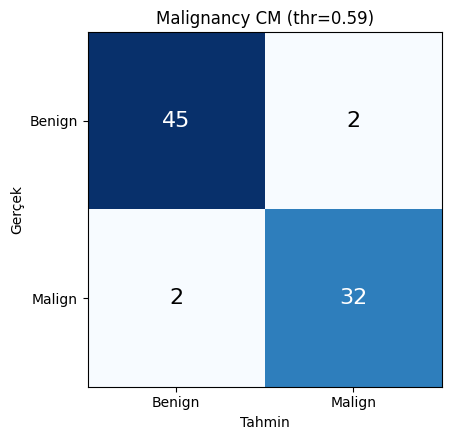

Acc 0.9506 | Sens 0.9412 | Spec 0.9574 | Prec 0.9412 | F1 0.9412


In [7]:
y=mal_all[m_mask].astype(int); p=mal_probs[m_mask]
fpr,tpr,thr_roc=roc_curve(y,p); best_t=thr_roc[np.argmax(tpr-fpr)]
pred=(p>=best_t).astype(int); cm=confusion_matrix(y,pred); tn,fp_,fn,tp=cm.ravel()
sens=tp/(tp+fn); spec=tn/(tn+fp_)
prec,rec,f1,_=precision_recall_fscore_support(y,pred,average='binary',zero_division=0)
acc=(tp+tn)/cm.sum()
fig,ax=plt.subplots(figsize=(5,4.5)); ax.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=16,color='white' if cm[i,j]>cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_xticklabels(['Benign','Malign']); ax.set_yticks([0,1]); ax.set_yticklabels(['Benign','Malign'])
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek'); ax.set_title(f'Malignancy CM (thr={best_t:.2f})')
plt.tight_layout(); plt.savefig('/content/confusion_matrix.png',dpi=120); plt.show()
print(f'Acc {acc:.4f} | Sens {sens:.4f} | Spec {spec:.4f} | Prec {prec:.4f} | F1 {f1:.4f}')

## 8. Dice dağılımı

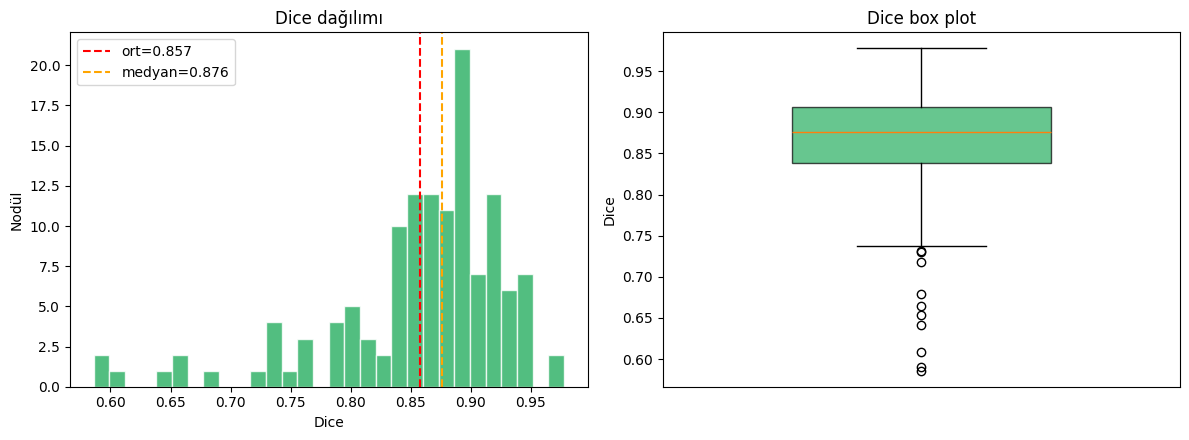

Dice ort 0.8573 medyan 0.8760 | >0.7 oranı 94.6%


In [8]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.5))
a1.hist(dice_arr,bins=30,color='#27ae60',alpha=0.8,edgecolor='white')
a1.axvline(dice_arr.mean(),color='red',ls='--',label=f'ort={dice_arr.mean():.3f}')
a1.axvline(np.median(dice_arr),color='orange',ls='--',label=f'medyan={np.median(dice_arr):.3f}')
a1.set_xlabel('Dice'); a1.set_ylabel('Nodül'); a1.set_title('Dice dağılımı'); a1.legend()
bp=a2.boxplot(dice_arr,patch_artist=True,widths=0.5); bp['boxes'][0].set_facecolor('#27ae60'); bp['boxes'][0].set_alpha(0.7)
a2.set_ylabel('Dice'); a2.set_title('Dice box plot'); a2.set_xticks([])
plt.tight_layout(); plt.savefig('/content/dice_dist.png',dpi=120); plt.show()
print(f'Dice ort {dice_arr.mean():.4f} medyan {np.median(dice_arr):.4f} | >0.7 oranı {(dice_arr>0.7).mean()*100:.1f}%')

## 9. Kalibrasyon (malignancy)

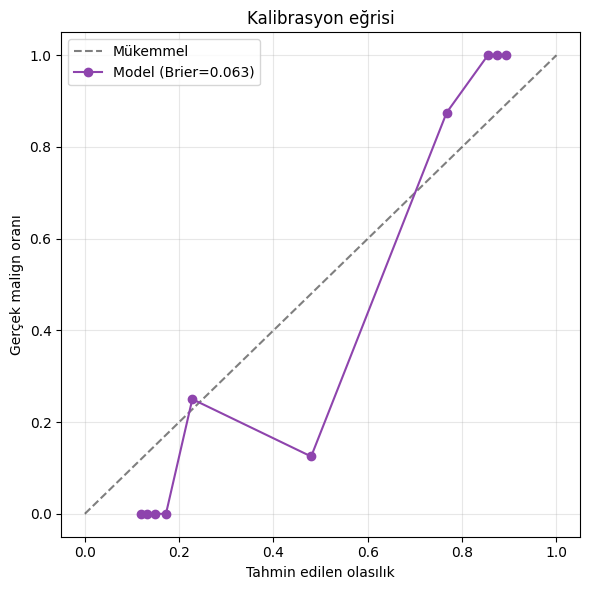

Brier score: 0.0634 (düşük=iyi)


In [9]:
fpos,mpred=calibration_curve(y,p,n_bins=10,strategy='quantile'); brier=brier_score_loss(y,p)
fig,ax=plt.subplots(figsize=(6,6)); ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Mükemmel')
ax.plot(mpred,fpos,'o-',color='#8e44ad',label=f'Model (Brier={brier:.3f})')
ax.set_xlabel('Tahmin edilen olasılık'); ax.set_ylabel('Gerçek malign oranı')
ax.set_title('Kalibrasyon eğrisi'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/calibration.png',dpi=120); plt.show()
print(f'Brier score: {brier:.4f} (düşük=iyi)')

---
# B) GERÇEK SCAN-LEVEL FROC

Ham CT taramalarından, LUNA16 aday listesiyle. Tarama başına yanlış pozitif ekseninde.

## 10. Test scan'leri + adayları (NPZ varsa)

In [10]:
froc_score=None; avail=[]
if RUN_SCAN_FROC:
    meta=json.load(open(SPLIT_META)); test_scans=set(meta['scans']['test'])
    cand=pd.read_csv(CANDIDATES_CSV); cand_test=cand[cand['seriesuid'].isin(test_scans)].copy()
    def sid_to_npz(sid): return os.path.join(NPZ_DIR, sid + '.npz')   # noktalı isim, replace YOK
    avail=[s for s in test_scans if os.path.exists(sid_to_npz(s))]
    print(f'Test taraması: {len(test_scans)} | NPZ mevcut: {len(avail)}')
    print(f'Test adayı: {len(cand_test)} (pozitif {int((cand_test["class"]==1).sum())}, negatif {int((cand_test["class"]==0).sum())})')
    if len(avail)==0:
        print('⚠️ NPZ bulunamadı — NPZ_DIR yolunu düzelt. Aranan örnek:', sid_to_npz(list(test_scans)[0]))
else:
    print('Scan-level FROC atlandı (RUN_SCAN_FROC=False)')

Test taraması: 90 | NPZ mevcut: 90
Test adayı: 55938 (pozitif 169, negatif 55769)


## 11. Adayları patch'le + model → FROC

In [13]:
TTA = True   # 4-yönlü (orijinal + 3 flip) ortalama; False yaparsan hızlı tek-geçiş

if RUN_SCAN_FROC and len(avail)>0:
    R=ROI//2
    def world_to_voxel(wx, wy, wz, origin, spacing):
        vz=(wz-origin[0])/spacing[0]; vy=(wy-origin[1])/spacing[1]; vx=(wx-origin[2])/spacing[2]
        return int(round(vz)), int(round(vy)), int(round(vx))
    def extract_patch(scan, cz, cy, cx):
        z0=cz-R; y0=cy-R; x0=cx-R
        pz0=max(0,-z0); pz1=max(0,(z0+ROI)-scan.shape[0])
        py0=max(0,-y0); py1=max(0,(y0+ROI)-scan.shape[1])
        px0=max(0,-x0); px1=max(0,(x0+ROI)-scan.shape[2])
        cz0=max(0,z0); cz1=min(scan.shape[0],z0+ROI)
        cy0=max(0,y0); cy1=min(scan.shape[1],y0+ROI)
        cx0=max(0,x0); cx1=min(scan.shape[2],x0+ROI)
        crop=scan[cz0:cz1,cy0:cy1,cx0:cx1]
        if any([pz0,pz1,py0,py1,px0,px1]):
            crop=np.pad(crop,((pz0,pz1),(py0,py1),(px0,px1)),mode='constant',constant_values=HU_CLIP[0])
        pc=np.clip(crop,HU_CLIP[0],HU_CLIP[1]).astype(np.float32)
        return (pc-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])

    @torch.no_grad()
    def predict_batch(xb):
        # xb: (B,1,64,64,64) tensor
        if not TTA:
            return torch.softmax(model(xb)['detection'],1)[:,1].cpu().numpy()
        probs=torch.softmax(model(xb)['detection'],1)[:,1]
        for dims in [(2,),(3,),(4,)]:   # z, y, x flip
            probs=probs+torch.softmax(model(torch.flip(xb,dims=dims))['detection'],1)[:,1]
        return (probs/4.0).cpu().numpy()

    rows=[]
    for sid in tqdm(avail,desc='Taramalar'):
        f=np.load(sid_to_npz(sid),allow_pickle=True); scan=f['scan']; origin=f['origin']; spacing=f['spacing']
        sc=cand_test[cand_test['seriesuid']==sid]
        if MAX_NEG_PER_SCAN is not None:
            pos=sc[sc['class']==1]; nn_=int((sc['class']==0).sum())
            neg=sc[sc['class']==0].sample(min(MAX_NEG_PER_SCAN,nn_),random_state=42); sc=pd.concat([pos,neg])
        patches=[]; mrows=[]
        for _,r in sc.iterrows():
            vz,vy,vx=world_to_voxel(r['coordX'],r['coordY'],r['coordZ'],origin,spacing)
            patches.append(extract_patch(scan,vz,vy,vx))
            mrows.append((sid,int(r['class']),float(r['coordX']),float(r['coordY']),float(r['coordZ'])))
        for s in range(0,len(patches),BATCH):
            xb=torch.from_numpy(np.stack(patches[s:s+BATCH])[:,None]).to(device)
            pr=predict_batch(xb)
            for j,pp in enumerate(pr):
                sid2,cls,cx,cy,cz=mrows[s+j]; rows.append((sid2,cls,float(pp),cx,cy,cz))
        del f,scan; gc.collect()
    res=pd.DataFrame(rows,columns=['seriesuid','cls','prob','coordX','coordY','coordZ'])
    print('Değerlendirilen aday:', len(res), '| pozitif:', int((res['cls']==1).sum()), '| TTA:', TTA)

Taramalar:   0%|          | 0/90 [00:00<?, ?it/s]

Değerlendirilen aday: 55938 | pozitif: 169 | TTA: True


**NMS + FROC (ikisini karşılaştırır):**

NMS sonrası aday: 49648/55938 (negatifler birleşti)


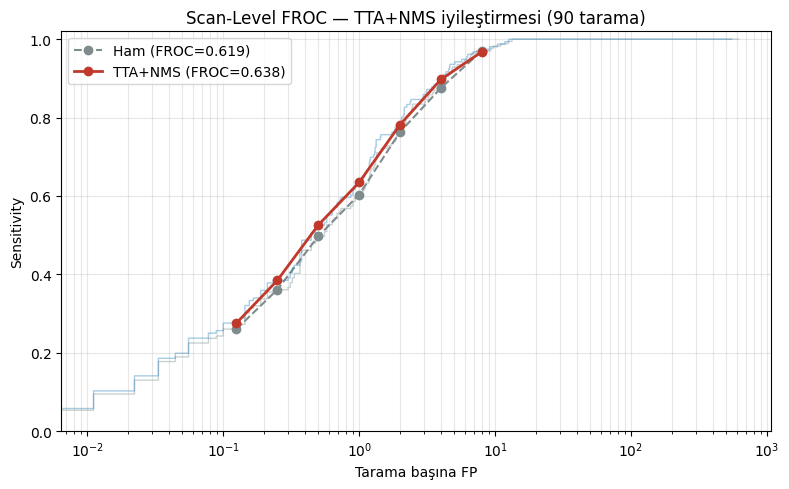

  @0.125 FP/scan: sens=0.2756
  @ 0.25 FP/scan: sens=0.3846
  @  0.5 FP/scan: sens=0.5256
  @    1 FP/scan: sens=0.6346
  @    2 FP/scan: sens=0.7821
  @    4 FP/scan: sens=0.8974
  @    8 FP/scan: sens=0.9679
  >>> İyileştirilmiş FROC: 0.6383 (ham: 0.6188) <<<


In [14]:
def compute_froc(df, label=''):
    n_scans=df['seriesuid'].nunique(); n_pos=int((df['cls']==1).sum())
    yy=df['cls'].values; pq=df['prob'].values; thr=np.unique(pq)[::-1]
    fps,sensv=[],[]
    for t in thr:
        prd=pq>=t; tp=int((prd&(yy==1)).sum()); fp=int((prd&(yy==0)).sum())
        sensv.append(tp/max(n_pos,1)); fps.append(fp/n_scans)
    fps=np.array(fps); sensv=np.array(sensv)
    pts=[0.125,0.25,0.5,1,2,4,8]
    fsens=[(sensv[fps<=fp].max() if (fps<=fp).any() else 0.0) for fp in pts]
    return fps,sensv,pts,fsens,float(np.mean(fsens))

def nms_world(df, radius_mm=8.0):
    """Her scan içinde, prob'a göre sırala; yarıçap içindeki düşük-prob adayları ele."""
    keep=[]
    for sid,g in df.groupby('seriesuid'):
        g=g.sort_values('prob',ascending=False).reset_index(drop=True)
        coords=g[['coordX','coordY','coordZ']].values; taken=np.zeros(len(g),bool); kept_idx=[]
        for i in range(len(g)):
            if taken[i]: continue
            kept_idx.append(i)
            d=np.linalg.norm(coords-coords[i],axis=1)
            taken|=(d<radius_mm)   # yakındakileri (kendisi dahil) işaretle
            taken[i]=True
        keep.append(g.iloc[kept_idx])
    return pd.concat(keep,ignore_index=True)

# Önce/sonra karşılaştır
fps0,sv0,pts,fs0,sc0=compute_froc(res,'ham')
res_nms=nms_world(res, radius_mm=8.0)
fps1,sv1,_,fs1,sc1=compute_froc(res_nms,'NMS')
print(f'NMS sonrası aday: {len(res_nms)}/{len(res)} (negatifler birleşti)')

fig,ax=plt.subplots(figsize=(8,5))
ax.plot(fps0,sv0,'-',color='#95a5a6',alpha=0.5,lw=1)
ax.plot(pts,fs0,'o--',color='#7f8c8d',lw=1.5,label=f'Ham (FROC={sc0:.3f})')
ax.plot(fps1,sv1,'-',color='#2980b9',alpha=0.4,lw=1)
ax.plot(pts,fs1,'o-',color='#c0392b',lw=2,label=f'TTA+NMS (FROC={sc1:.3f})')
ax.set_xscale('log'); ax.set_xlabel('Tarama başına FP'); ax.set_ylabel('Sensitivity')
ax.set_title(f'Scan-Level FROC — TTA+NMS iyileştirmesi ({res["seriesuid"].nunique()} tarama)')
ax.set_ylim(0,1.02); ax.grid(alpha=0.3,which='both'); ax.legend()
plt.tight_layout(); plt.savefig('/content/froc_improved.png',dpi=120); plt.show()
froc_score=sc1
for fp,se in zip(pts,fs1): print(f'  @{fp:>5} FP/scan: sens={se:.4f}')
print(f'  >>> İyileştirilmiş FROC: {sc1:.4f} (ham: {sc0:.4f}) <<<')

## 12. Özet tablo

In [15]:
print('='*60); print('  TEST SETİ — DEĞERLENDİRME ÖZETİ (v1)'); print('='*60)
print(f'  Detection AUC:     {d_auc:.4f}  [%95 CI {d_lo:.4f}-{d_hi:.4f}]')
print(f'  Malignancy AUC:    {m_auc:.4f}  [%95 CI {m_lo:.4f}-{m_hi:.4f}]')
print(f'  Malignancy Sens:   {sens:.4f}  Spec {spec:.4f}  F1 {f1:.4f}')
print(f'  Segmentation Dice: {dice_arr.mean():.4f}  [%95 CI {dl:.4f}-{dh:.4f}]')
print(f'  Kalibrasyon Brier: {brier:.4f}')
if froc_score is not None:
    print(f'  Scan-level FROC:   {froc_score:.4f}')
print('='*60)
imgs='confusion_matrix.png, dice_dist.png, calibration.png'
if froc_score is not None: imgs+=', froc_scanlevel.png'
print('  Görseller:', imgs)

  TEST SETİ — DEĞERLENDİRME ÖZETİ (v1)
  Detection AUC:     0.9981  [%95 CI 0.9961-0.9995]
  Malignancy AUC:    0.9862  [%95 CI 0.9621-1.0000]
  Malignancy Sens:   0.9412  Spec 0.9574  F1 0.9412
  Segmentation Dice: 0.8573  [%95 CI 0.8447-0.8700]
  Kalibrasyon Brier: 0.0634
  Scan-level FROC:   0.6383
  Görseller: confusion_matrix.png, dice_dist.png, calibration.png, froc_scanlevel.png


In [16]:
for rmm in [8, 10, 12, 15]:
    rn = nms_world(res, radius_mm=rmm)
    _,_,_,_,sc = compute_froc(rn)
    print(f'radius={rmm}mm → FROC={sc:.4f}, aday={len(rn)}')

radius=8mm → FROC=0.6383, aday=49648
radius=10mm → FROC=0.6535, aday=43941
radius=12mm → FROC=0.6703, aday=37623
radius=15mm → FROC=0.7143, aday=29027
